# 10 - Segmentação de Reservas (Agrupamento)

Até aqui o projeto foi todo de aprendizagem supervisionada. Este notebook faz
uma análise não supervisionada: agrupo as reservas por perfil, sem usar a
variável de cancelamento, e depois descrevo cada grupo.

O objetivo não é prever nada. É entender **que tipos de reserva existem** e
como o risco de cancelamento se distribui entre esses perfis. O conteúdo da
disciplina inclui problemas de agrupamento, então também serve para cobrir
essa parte.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
df = preparar()

# uso um conjunto pequeno de variáveis numéricas fáceis de interpretar
vars_cluster = [
    "lead_time", "adr", "total_nights", "total_guests",
    "total_of_special_requests", "previous_cancellations",
    "required_car_parking_spaces",
]
print("variáveis usadas no agrupamento:", vars_cluster)

X = df[vars_cluster].copy()
Xs = StandardScaler().fit_transform(X)

variáveis usadas no agrupamento: ['lead_time', 'adr', 'total_nights', 'total_guests', 'total_of_special_requests', 'previous_cancellations', 'required_car_parking_spaces']


## 2. Número de grupos

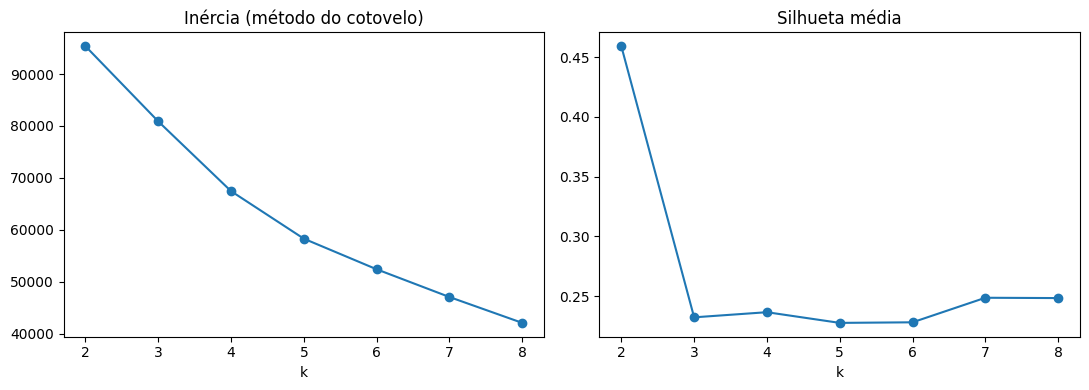

In [3]:
amostra = pd.DataFrame(Xs, columns=vars_cluster).sample(15000, random_state=42)

inercia, silhueta = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(amostra)
    inercia.append(km.inertia_)
    silhueta.append(silhouette_score(amostra, km.labels_, sample_size=3000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inercia, marker="o")
ax[0].set_title("Inércia (método do cotovelo)")
ax[0].set_xlabel("k")
ax[1].plot(list(ks), silhueta, marker="o")
ax[1].set_title("Silhueta média")
ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

In [4]:
k = 4
print("número de grupos escolhido:", k)

número de grupos escolhido: 4


Escolho `k = 4`: é onde o ganho na inércia começa a diminuir e a silhueta
ainda está razoável. Grupos demais deixariam a leitura confusa.

## 3. Perfil de cada grupo

In [5]:
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
df["grupo"] = km.labels_

perfil = df.groupby("grupo")[vars_cluster].mean()
perfil["reservas"] = df.groupby("grupo").size()
perfil["taxa_cancelamento"] = df.groupby("grupo")[ALVO].mean()
perfil

,lead_time,adr,total_nights,total_guests,total_of_special_requests,previous_cancellations,required_car_parking_spaces,reservas,taxa_cancelamento
grupo,,,,,,,,,
0,115.388,83.159,2.944,1.745,0.211,0.082,0.000,74276,0.428
1,55.023,113.241,3.158,2.106,0.829,0.021,1.006,7406,0.000
2,193.961,62.045,3.472,1.972,0.100,19.844,0.017,180,0.856
3,90.976,137.221,4.438,2.394,1.240,0.016,0.000,37347,0.329


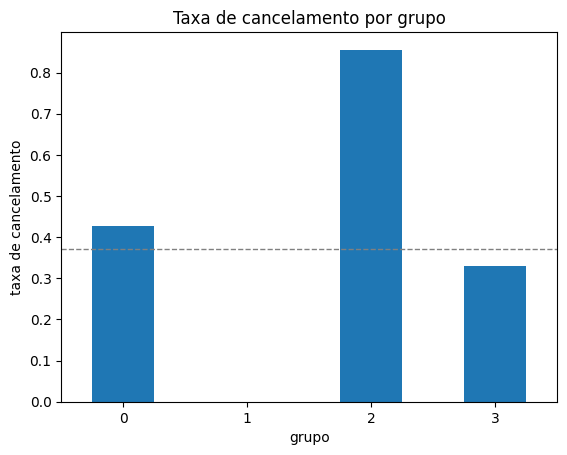

In [6]:
df.groupby("grupo")[ALVO].mean().plot(kind="bar")
plt.axhline(df[ALVO].mean(), color="gray", linestyle="--", linewidth=1)
plt.title("Taxa de cancelamento por grupo")
plt.xlabel("grupo")
plt.ylabel("taxa de cancelamento")
plt.xticks(rotation=0)
plt.show()

Os grupos têm taxas de cancelamento bem diferentes:

- um grupo grande de reservas mais antecipadas, tarifa média e poucas
  solicitações, que cancela acima da média;
- um grupo com vaga de estacionamento reservada, que quase não cancela;
- um grupo pequeno de clientes com muitos cancelamentos anteriores, que quase
  sempre cancela;
- um grupo de estadias mais longas e caras, com risco perto da média.

É coerente com a EDA e com a importância das variáveis do notebook 08.

## 4. Grupos x risco previsto pelo modelo

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

treino, teste = separar_treino_teste(df)
variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS

preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])
peso_pos = (treino[ALVO] == 0).sum() / (treino[ALVO] == 1).sum()
modelo = Pipeline([("prep", preproc),
                   ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                         subsample=0.9, scale_pos_weight=peso_pos,
                                         eval_metric="logloss", random_state=42, n_jobs=4))])
modelo.fit(treino[variaveis], treino[ALVO])

teste = teste.copy()
teste["prob"] = modelo.predict_proba(teste[variaveis])[:, 1]

(teste.groupby("grupo")
      .agg(reservas=("grupo", "size"),
           risco_medio_previsto=("prob", "mean"),
           taxa_cancel_real=(ALVO, "mean"))
      .round(3))

,reservas,risco_medio_previsto,taxa_cancel_real
grupo,,,
0,11088,0.510,0.479
1,1236,0.001,0.000
3,11518,0.354,0.385


O risco médio que o modelo atribui a cada grupo acompanha a taxa real de
cancelamento observada. Ou seja, os grupos do KMeans e o modelo
supervisionado contam a mesma história, por caminhos diferentes.

## 5. Leitura de negócio

Uma forma de resumir os grupos:

- **reservas antecipadas e simples**: `lead_time` alto, poucas solicitações,
  sem estacionamento. É o maior grupo e o de maior risco. Vale acompanhar de
  perto e pensar em política de depósito;
- **reservas com estacionamento**: quem reserva vaga quase nunca cancela;
- **clientes com histórico de cancelamento**: grupo pequeno, mas de risco
  altíssimo. Faz sentido um tratamento à parte (pré-pagamento, confirmação);
- **estadias longas e mais caras**: risco perto da média, mas pesam mais na
  receita, então merecem atenção proporcional.

Esses nomes são uma interpretação dos números acima, não uma classificação
oficial. Servem para a conversa com a área de reservas.

## 6. O que fica

- as reservas se separam em poucos perfis com risco de cancelamento bem
  distinto;
- o agrupamento não usa a variável alvo, mas chega a grupos que fazem sentido
  quando olho a taxa de cancelamento depois;
- o risco previsto pelo modelo final acompanha os grupos;
- para o hotel, isso permite ações por perfil além do score individual.